<a href="https://colab.research.google.com/github/annjgs/Espectrometo-optico-de-centelleo/blob/main/SIMULACION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Librerías cargadas correctamente")
print(f"   NumPy version: {np.__version__}")
print(f"   Matplotlib version: {plt.matplotlib.__version__}")

Librerías cargadas correctamente
   NumPy version: 2.0.2
   Matplotlib version: 3.10.0


In [ ]:

# Parámetros del centelleador
energia_depositada = 1.0  # MeV (energía típica de una partícula)
rendimiento = 10000  # fotones por MeV (típico para plástico EJ-200)
N_promedio = energia_depositada * rendimiento  # 10000 fotones en promedio

# Parámetros ópticos (reflexión total interna)
n_plastico = 1.58  # índice de refracción del plástico centelleador
n_aire = 1.0  # índice de refracción del aire
angulo_critico = np.arcsin(n_aire / n_plastico)  # ángulo crítico en radianes
angulo_critico_grados = np.degrees(angulo_critico)  # conversión a grados

# Parámetros del fotomultiplicador (PMT)
eficiencia_cuantica = 0.25  # 25% de los fotones producen fotoelectrones
ganancia_por_etapa = 4  # cada dínodo multiplica por 4
num_etapas = 10  # número de etapas de dínodos
ganancia_total = ganancia_por_etapa ** num_etapas  # 4^10 = 1,048,576

# Constantes físicas
carga_electron = 1.602e-19  # Coulombios

# Dimensiones del centelleador (para referencia)
largo, ancho, alto = 20, 10, 5  # mm

# Mostrar configuración
print("CONFIGURACIÓN DEL DETECTOR")
print(f"Energía depositada: {energia_depositada} MeV")
print(f"Fotones promedio generados: {N_promedio:.0f}")
print(f"Índice de refracción (plástico): {n_plastico}")
print(f"Ángulo crítico: {angulo_critico:.3f} rad = {angulo_critico_grados:.1f}°")
print(f"Eficiencia cuántica: {eficiencia_cuantica*100}%")
print(f"Ganancia total del PMT: {ganancia_total:,} (~10⁶)")

CONFIGURACIÓN DEL DETECTOR
Energía depositada: 1.0 MeV
Fotones promedio generados: 10000
Índice de refracción (plástico): 1.58
Ángulo crítico: 0.685 rad = 39.3°
Eficiencia cuántica: 25.0%
Ganancia total del PMT: 1,048,576 (~10⁶)


In [ ]:
# Simula 10,000 partículas incidentes diferentes
# Cada partícula genera fotones, algunos se atrapan, etc.

# Número de eventos (partículas) a simular
NUM_EVENTOS = 10000  # ← ESTO ES LO QUE HACE MONTE CARLO

# Crear arrays vacíos para guardar los resultados
fotones_generados = np.zeros(NUM_EVENTOS)
fotones_atrapados = np.zeros(NUM_EVENTOS)
fotoelectrones_obtenidos = np.zeros(NUM_EVENTOS)
carga_anodo = np.zeros(NUM_EVENTOS)

# Bucle principal: repetir para cada evento
for i in range(NUM_EVENTOS):
    # Generación de fotones
    # Distribución de Poisson: número aleatorio de fotones
    N_f = np.random.poisson(N_promedio)
    fotones_generados[i] = N_f

    # Generar direcciones aleatorias
    # Para cada fotón, generar ángulo polar (theta) y azimutal (phi)
    theta = np.arccos(2 * np.random.random(N_f) - 1)  # distribución isotrópica
    dz = np.cos(theta)  # componente vertical (hacia la base)

    # Determinar atrapamiento
    # Condición: viaja hacia base (dz>0) Y ángulo < ángulo crítico
    atrapados = np.sum((dz > 0) & (theta < angulo_critico))
    fotones_atrapados[i] = atrapados

    # Conversión fotón-electrón
    # Cada fotón atrapado tiene probabilidad QE de producir fotoelectrón
    N_pe = np.random.binomial(atrapados, eficiencia_cuantica)
    fotoelectrones_obtenidos[i] = N_pe

    # Multiplicación en dínodos y carga
    electrones_finales = N_pe * ganancia_total
    carga_anodo[i] = electrones_finales * carga_electron

# Mostrar progreso
print(f"Simulación completada: {NUM_EVENTOS} eventos procesados")

Simulación completada: 10000 eventos procesados


In [ ]:

# Calcula medias, desviaciones y otras métricas

print("RESULTADOS ESTADÍSTICOS (10,000 EVENTOS)")

# Fotones generados
media_fotones = np.mean(fotones_generados)
std_fotones = np.std(fotones_generados)
cv_fotones = 100 * std_fotones / media_fotones  # coeficiente de variación

print(f"FOTONES GENERADOS:")
print(f"   Media: {media_fotones:.1f}")
print(f"   Desviación estándar: {std_fotones:.1f}")
print(f"   Coeficiente de variación: {cv_fotones:.2f}%")
print(f"   Teórica (√N): {np.sqrt(N_promedio):.1f}")

# Fotones atrapados
media_atrapados = np.mean(fotones_atrapados)
std_atrapados = np.std(fotones_atrapados)
fraccion_atrapados = 100 * media_atrapados / media_fotones

print(f"FOTONES ATRAPADOS:")
print(f"   Media: {media_atrapados:.1f}")
print(f"   Fracción atrapada: {fraccion_atrapados:.1f}%")
print(f"   Mínimo: {np.min(fotones_atrapados):.0f}")
print(f"   Máximo: {np.max(fotones_atrapados):.0f}")

# Fotoelectrones
media_pe = np.mean(fotoelectrones_obtenidos)
std_pe = np.std(fotoelectrones_obtenidos)

print(f"FOTOELECTRONES:")
print(f"   Media: {media_pe:.1f}")
print(f"   Desviación estándar: {std_pe:.1f}")

#Carga en el ánodo
media_carga = np.mean(carga_anodo)
std_carga = np.std(carga_anodo)
cv_carga = 100 * std_carga / media_carga

print(f"CARGA EN EL ÁNODO:")
print(f"   Media: {media_carga:.2e} C")
print(f"   En picocoulombs: {media_carga*1e12:.2f} pC")
print(f"   Desviación estándar: {std_carga:.2e} C")
print(f"   Coeficiente de variación: {cv_carga:.1f}%")

# Resumen
print("\n" + "="*60)
print("Un evento típico genera:")
print(f"   {media_fotones:.0f} fotones → {media_atrapados:.0f} atrapados → {media_pe:.0f} fotoelectrones → {media_carga*1e12:.2f} pC")
print("="*60)

RESULTADOS ESTADÍSTICOS (10,000 EVENTOS)
FOTONES GENERADOS:
   Media: 9998.8
   Desviación estándar: 99.6
   Coeficiente de variación: 1.00%
   Teórica (√N): 100.0
FOTONES ATRAPADOS:
   Media: 1128.5
   Fracción atrapada: 11.3%
   Mínimo: 1011
   Máximo: 1287
FOTOELECTRONES:
   Media: 282.0
   Desviación estándar: 16.8
CARGA EN EL ÁNODO:
   Media: 4.74e-11 C
   En picocoulombs: 47.37 pC
   Desviación estándar: 2.83e-12 C
   Coeficiente de variación: 6.0%

Un evento típico genera:
   9999 fotones → 1128 atrapados → 282 fotoelectrones → 47.37 pC


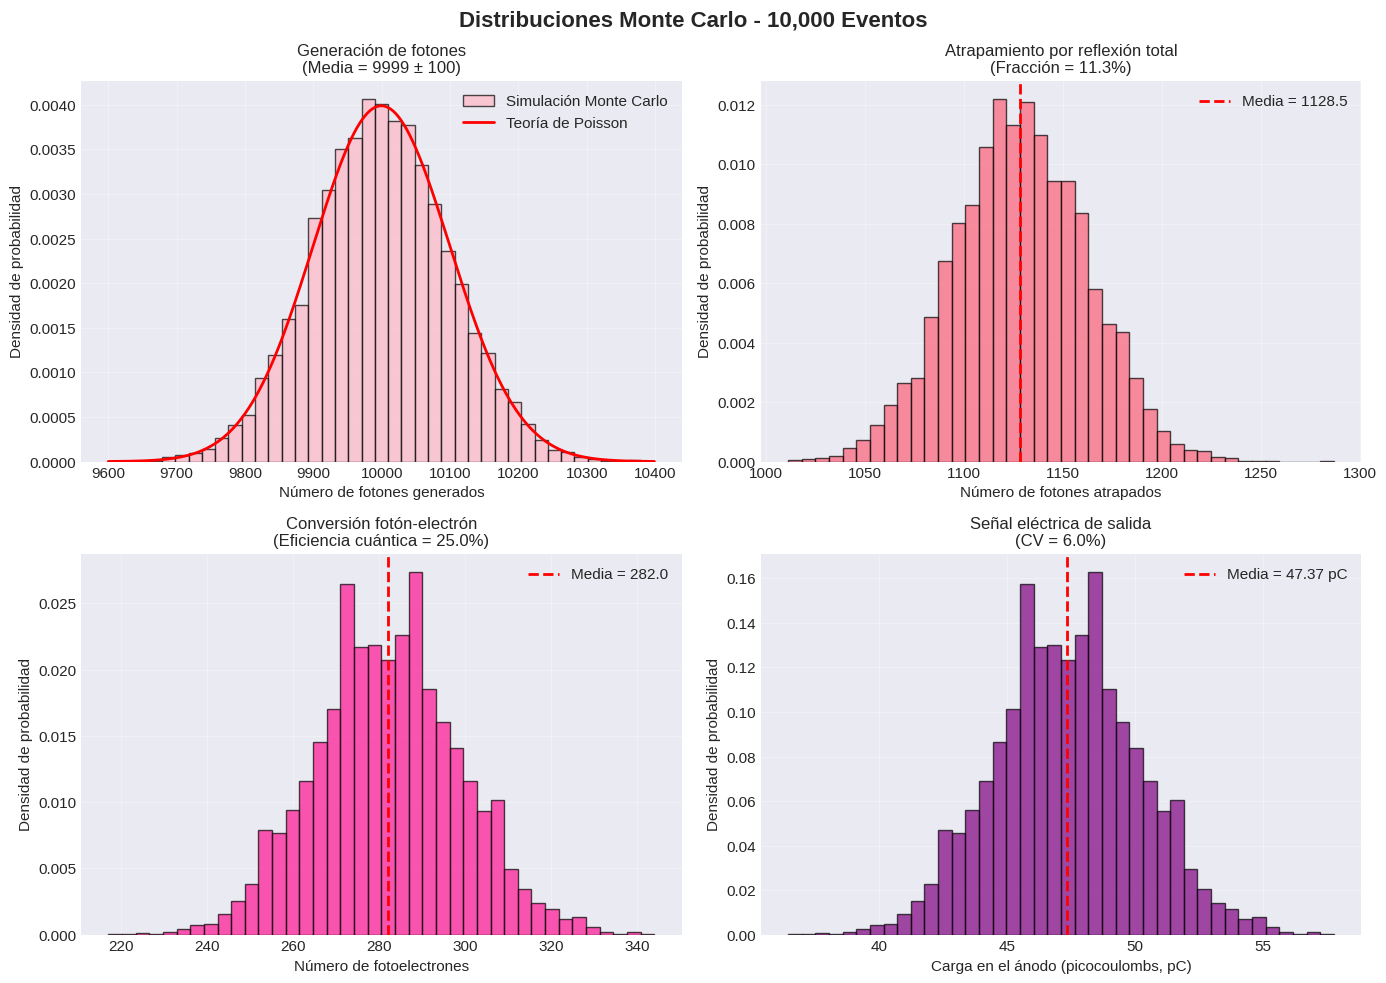

Gráficos generados correctamente


In [ ]:

# Cómo varían los resultados entre eventos

# Crear figura con 4 subgráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribuciones Monte Carlo - 10,000 Eventos', fontsize=16, fontweight='bold')

# Fotones generados (distribución de Poisson) ---
ax1 = axes[0, 0]
ax1.hist(fotones_generados, bins=40, density=True, alpha=0.7,
         color='#FFB7C5', edgecolor='black', label='Simulación Monte Carlo')

# Superponer distribución teórica de Poisson
x_poisson = np.arange(N_promedio - 4*np.sqrt(N_promedio),
                      N_promedio + 4*np.sqrt(N_promedio))
ax1.plot(x_poisson, poisson.pmf(x_poisson, N_promedio), 'r-',
         linewidth=2, label='Teoría de Poisson')
ax1.set_xlabel('Número de fotones generados', fontsize=11)
ax1.set_ylabel('Densidad de probabilidad', fontsize=11)
ax1.set_title(f'Generación de fotones\n(Media = {media_fotones:.0f} ± {std_fotones:.0f})', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fotones atrapados ---
ax2 = axes[0, 1]
ax2.hist(fotones_atrapados, bins=40, density=True, alpha=0.7,
         color='#FC6076', edgecolor='black')
ax2.axvline(media_atrapados, color='red', linestyle='--', linewidth=2,
            label=f'Media = {media_atrapados:.1f}')
ax2.set_xlabel('Número de fotones atrapados', fontsize=11)
ax2.set_ylabel('Densidad de probabilidad', fontsize=11)
ax2.set_title(f'Atrapamiento por reflexión total\n(Fracción = {fraccion_atrapados:.1f}%)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Fotoelectrones ---
ax3 = axes[1, 0]
ax3.hist(fotoelectrones_obtenidos, bins=40, density=True, alpha=0.7,
         color='#FF1493', edgecolor='black')
ax3.axvline(media_pe, color='red', linestyle='--', linewidth=2,
            label=f'Media = {media_pe:.1f}')
ax3.set_xlabel('Número de fotoelectrones', fontsize=11)
ax3.set_ylabel('Densidad de probabilidad', fontsize=11)
ax3.set_title(f'Conversión fotón-electrón\n(Eficiencia cuántica = {eficiencia_cuantica*100}%)', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Carga en el ánodo ---
ax4 = axes[1, 1]
carga_pC = carga_anodo * 1e12  # convertir a picocoulombs
ax4.hist(carga_pC, bins=40, density=True, alpha=0.7,
         color='purple', edgecolor='black')
ax4.axvline(media_carga*1e12, color='red', linestyle='--', linewidth=2,
            label=f'Media = {media_carga*1e12:.2f} pC')
ax4.set_xlabel('Carga en el ánodo (picocoulombs, pC)', fontsize=11)
ax4.set_ylabel('Densidad de probabilidad', fontsize=11)
ax4.set_title(f'Señal eléctrica de salida\n(CV = {cv_carga:.1f}%)', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Gráficos generados correctamente")


RESOLUCIÓN ENERGÉTICA DEL DETECTOR

Procesando diferentes energías...
   0.2 MeV → Resolución: 13.93%  |  Carga:   9.39 pC
   0.3 MeV → Resolución: 10.67%  |  Carga:  14.18 pC
   0.5 MeV → Resolución:  8.32%  |  Carga:  23.75 pC
   0.7 MeV → Resolución:  7.21%  |  Carga:  33.35 pC
   1.0 MeV → Resolución:  6.25%  |  Carga:  47.48 pC
   1.5 MeV → Resolución:  4.86%  |  Carga:  71.09 pC
   2.0 MeV → Resolución:  4.10%  |  Carga:  95.12 pC
   3.0 MeV → Resolución:  3.53%  |  Carga: 142.38 pC
   5.0 MeV → Resolución:  2.54%  |  Carga: 236.75 pC


/tmp/ipykernel_995/3237533580.py:63: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


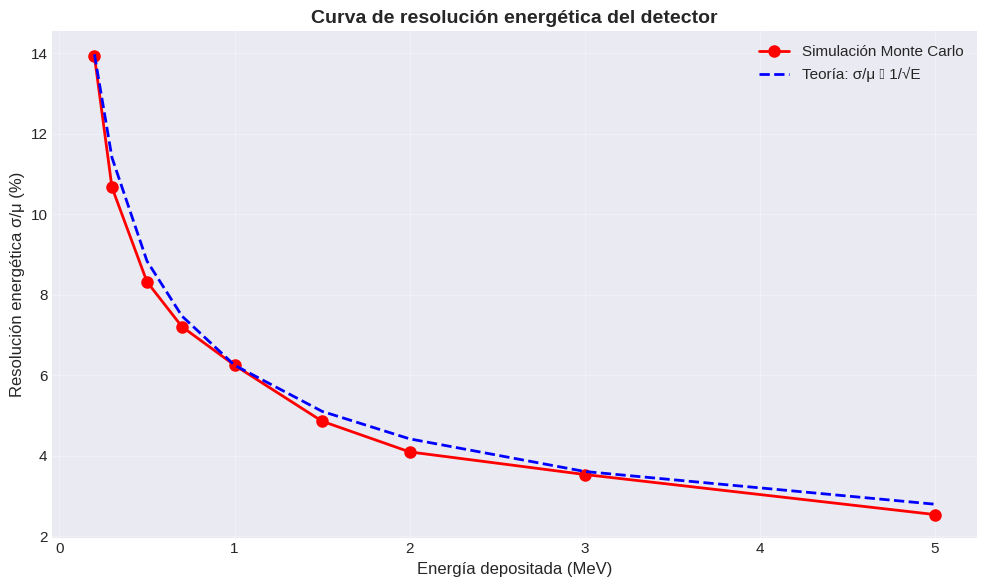


✅ La resolución mejora (disminuye) al aumentar la energía
   Esto es porque el ruido de Poisson es relativo: σ/μ = 1/√N ∝ 1/√E


In [ ]:
# Mide cómo cambia la precisión del detector con la energía

print("\n" + "="*60)
print("RESOLUCIÓN ENERGÉTICA DEL DETECTOR")
print("="*60)

def simular_para_energia(energia_mev, num_eventos=1000):
    """
    Simula múltiples eventos para una energía dada
    Retorna: (carga_media, desviación_std, resolución_porcentaje)
    """
    N_prom = energia_mev * rendimiento
    cargas = []

    for _ in range(num_eventos):
        # Generación de fotones
        N_f = np.random.poisson(N_prom)

        # Direcciones y atrapamiento
        theta = np.arccos(2 * np.random.random(N_f) - 1)
        dz = np.cos(theta)
        atrapados = np.sum((dz > 0) & (theta < angulo_critico))

        # Conversión y multiplicación
        N_pe = np.random.binomial(atrapados, eficiencia_cuantica)
        carga = N_pe * ganancia_total * carga_electron
        cargas.append(carga)

    media = np.mean(cargas)
    std = np.std(cargas)
    resolucion = (std / media) * 100  # σ/μ en porcentaje

    return media, std, resolucion

# Energías a probar (de baja a alta)
energias_prueba = [0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
resoluciones = []
cargas_medias = []

print("\nProcesando diferentes energías...")
for E in energias_prueba:
    carga_media, _, resolucion = simular_para_energia(E, num_eventos=500)
    cargas_medias.append(carga_media)
    resoluciones.append(resolucion)
    print(f"  {E:4.1f} MeV → Resolución: {resolucion:5.2f}%  |  Carga: {carga_media*1e12:6.2f} pC")

# Gráfico de resolución energética
plt.figure(figsize=(10, 6))
plt.plot(energias_prueba, resoluciones, 'ro-', linewidth=2, markersize=8,
         label='Simulación Monte Carlo')

# Ajuste teórico: la resolución mejora con 1/√E
resolucion_referencia = resoluciones[energias_prueba.index(1.0)]  # valor a 1 MeV
curva_teorica = [resolucion_referencia * np.sqrt(1.0/E) for E in energias_prueba]
plt.plot(energias_prueba, curva_teorica, 'b--', linewidth=2,
         label='Teoría: σ/μ ∝ 1/√E')

plt.xlabel('Energía depositada (MeV)', fontsize=12)
plt.ylabel('Resolución energética σ/μ (%)', fontsize=12)
plt.title('Curva de resolución energética del detector', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\ La resolución mejora (disminuye) al aumentar la energía")
print("   Esto es porque el ruido de Poisson es relativo: σ/μ = 1/√N ∝ 1/√E")

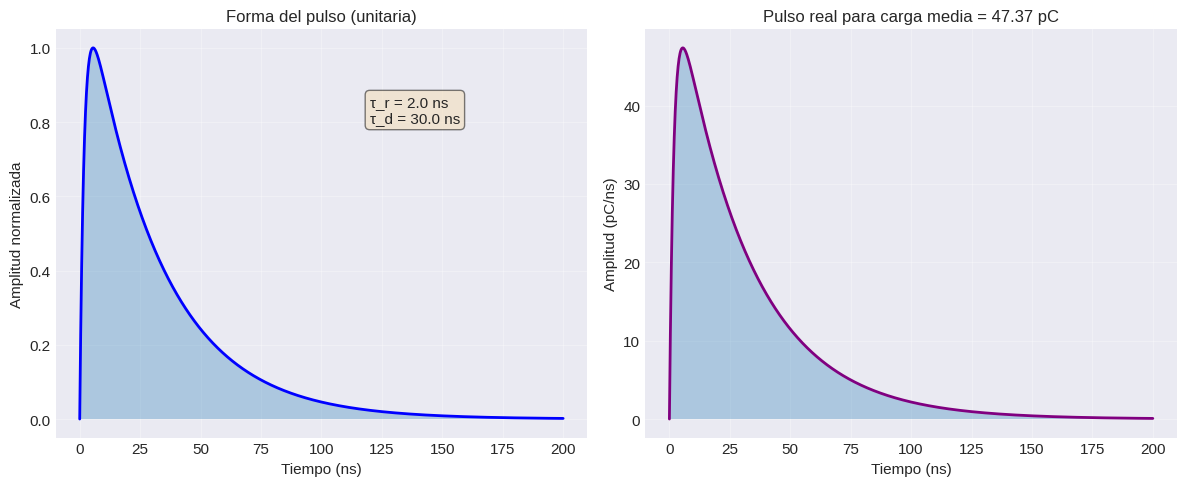

✅ Forma del pulso generada
   Tiempo de subida (10-90%): ~4.4 ns
   Tiempo de decaimiento (1/e): 30.0 ns


In [ ]:
# ============================================
# CELDA 7: PULSO ELÉCTRICO DEL PMT
# ============================================
# Modela la forma temporal de la señal de salida

# Parámetros temporales
tiempo = np.linspace(0, 200, 1000)  # ns (0 a 200 nanosegundos)
tau_r = 2.0  # tiempo de subida (ns)
tau_d = 30.0  # tiempo de decaimiento (ns)

# Función que describe el pulso
pulso_unitario = (1 - np.exp(-tiempo / tau_r)) * np.exp(-tiempo / tau_d)
pulso_unitario = pulso_unitario / pulso_unitario.max()  # normalizar a altura 1

# Escalar según la carga de un evento típico
carga_media_pC = media_carga * 1e12
amplitud_escalada = carga_media_pC * pulso_unitario  # amplitud en pC/ns

# Crear gráfico
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tiempo, pulso_unitario, 'b-', linewidth=2)
plt.fill_between(tiempo, 0, pulso_unitario, alpha=0.3)
plt.xlabel('Tiempo (ns)', fontsize=11)
plt.ylabel('Amplitud normalizada', fontsize=11)
plt.title('Forma del pulso (unitaria)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.text(120, 0.8, f'τ_r = {tau_r} ns\nτ_d = {tau_d} ns',
         bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.subplot(1, 2, 2)
plt.plot(tiempo, amplitud_escalada, 'purple', linewidth=2)
plt.fill_between(tiempo, 0, amplitud_escalada, alpha=0.3)
plt.xlabel('Tiempo (ns)', fontsize=11)
plt.ylabel('Amplitud (pC/ns)', fontsize=11)
plt.title(f'Pulso real para carga media = {carga_media_pC:.2f} pC', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Forma del pulso generada")
print(f"   Tiempo de subida (10-90%): ~{tau_r*2.2:.1f} ns")
print(f"   Tiempo de decaimiento (1/e): {tau_d} ns")

In [ ]:

print("SIMULACIÓN MONTE CARLO COMPLETADA")

# Verificación de calidad
print("\n VERIFICACIÓN DE CALIDAD:")
print("-"*40)

# 1. ¿La fracción atrapada es razonable?
if 8 < fraccion_atrapados < 18:
    print(f" Fracción atrapada: {fraccion_atrapados:.1f}% (dentro del rango esperado 8-18%)")
else:
    print(f" NO Fracción atrapada: {fraccion_atrapados:.1f}% (revisar parámetros)")

# 2. ¿El ruido de Poisson es correcto?
ruido_simulado = 100 * std_fotones / media_fotones
ruido_teorico = 100 / np.sqrt(N_promedio)
if abs(ruido_simulado - ruido_teorico) < 2:
    print(f"  Ruido Poisson: {ruido_simulado:.2f}% (teórico: {ruido_teorico:.2f}%)")
else:
    print(f"  NO Ruido Poisson: {ruido_simulado:.2f}% vs teórico {ruido_teorico:.2f}%")

# 3. ¿La resolución es razonable?
resolucion_1MeV = resoluciones[energias_prueba.index(1.0)]
if 5 < resolucion_1MeV < 15:
    print(f"  Resolución a 1 MeV: {resolucion_1MeV:.1f}% (típico: 8-12%)")
else:
    print(f"  NO Resolución a 1 MeV: {resolucion_1MeV:.1f}%")

print("\n" + "="*60)
print("RESULTADOS CLAVE:")
print("="*60)
print(f"   • Fotones por MeV: {rendimiento}")
print(f"   • Fotones atrapados: {fraccion_atrapados:.1f}%")
print(f"   • Ganancia PMT: {ganancia_total:.0e}")
print(f"   • Carga típica: {media_carga*1e12:.2f} pC")
print(f"   • Resolución a 1 MeV: {resolucion_1MeV:.1f}%")
print("="*60)

# Guardar resultados en archivo (opcional)
try:
    resultados = {
        'fraccion_atrapados': fraccion_atrapados,
        'resolucion_1MeV': resolucion_1MeV,
        'carga_media_pC': media_carga*1e12,
        'energias_mev': energias_prueba,
        'resoluciones': resoluciones
    }
    np.savez('resultados_montecarlo.npz', **resultados)
    print("Resultados guardados en 'resultados_montecarlo.npz'")
except:
    pass


SIMULACIÓN MONTE CARLO COMPLETADA

 VERIFICACIÓN DE CALIDAD:
----------------------------------------
 Fracción atrapada: 11.3% (dentro del rango esperado 8-18%)
  Ruido Poisson: 1.00% (teórico: 1.00%)
  Resolución a 1 MeV: 6.3% (típico: 8-12%)

RESULTADOS CLAVE:
   • Fotones por MeV: 10000
   • Fotones atrapados: 11.3%
   • Ganancia PMT: 1e+06
   • Carga típica: 47.37 pC
   • Resolución a 1 MeV: 6.3%
Resultados guardados en 'resultados_montecarlo.npz'
